<a href="https://colab.research.google.com/github/Gangamma-yn/Gangamma-yn/blob/main/day4_hugging_face_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.day 4 first program  hugging face image classification

In [ ]:
!pip install transformers datasets torch torchvision pillow matplotlib kaggle -q

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"gangammayn","key":"b5369f919f08f6f33e717f45f95ddf17"}'}

In [ ]:
import os

# Create Kaggle folder
os.makedirs("/root/.kaggle", exist_ok=True)

# Copy kaggle.json
!cp kaggle.json /root/.kaggle/

# Give permission
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle Configured Successfully")

Kaggle Configured Successfully


In [ ]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:05<00:00, 70.7MB/s]



In [ ]:
import zipfile

zip_path = "/content/intel-image-classification.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/intel_dataset")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
import os

print(os.listdir("/content/intel_dataset"))

['seg_pred', 'seg_train', 'seg_test']


In [ ]:
['seg_test', 'seg_train', 'seg_pred']

In [ ]:
test_path = "/content/intel_dataset/seg_test/seg_test"

print(os.listdir(test_path))

['sea', 'glacier', 'mountain', 'buildings', 'forest', 'street']


In [ ]:
test_path = "/content/intel_dataset/seg_test/seg_test"

print(os.listdir(test_path))

['sea', 'glacier', 'mountain', 'buildings', 'forest', 'street']


In [ ]:
glacier_path = "/content/intel_dataset/seg_test/seg_test/glacier"

images = os.listdir(glacier_path)

print(images[:10])

['21865.jpg', '21025.jpg', '23962.jpg', '22742.jpg', '20287.jpg', '21766.jpg', '23929.jpg', '23447.jpg', '21437.jpg', '20887.jpg']


In [ ]:
from transformers import AutoImageProcessor
from transformers import AutoModelForImageClassification

from PIL import Image

import torch
import matplotlib.pyplot as plt

In [ ]:
model_name = "google/vit-base-patch16-224"

processor = AutoImageProcessor.from_pretrained(model_name)

model = AutoModelForImageClassification.from_pretrained(model_name)

print("Model Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Model Loaded Successfully


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Ensure true_labels and predicted_labels are defined (they should be after running the previous cell)
if 'true_labels' not in globals() or 'predicted_labels' not in globals():
    print("Error: 'true_labels' or 'predicted_labels' are not defined. Please run the cell that generates these lists first.")
else:
    accuracy = accuracy_score(true_labels, predicted_labels)
    # For multiclass classification with potentially unmatched labels, use 'weighted' average.
    # zero_division=0 prevents warnings when a class has no true or predicted samples.
    precision = precision_score(true_labels, predicted_labels, average='weighted', zero_division=0)
    recall = recall_score(true_labels, predicted_labels, average='weighted', zero_division=0)
    f1 = f1_score(true_labels, predicted_labels, average='weighted', zero_division=0)

    print("Accuracy:", accuracy)
    print("Precision (weighted):", precision)
    print("Recall (weighted):", recall)
    print("F1-Score (weighted):", f1)

    print("\nTrue Labels:", true_labels)
    print("Predicted Labels:", predicted_labels)

Accuracy: 0.0
Precision (weighted): 0.0
Recall (weighted): 0.0
F1-Score (weighted): 0.0

True Labels: ['forest', 'forest', 'forest', 'forest', 'forest']
Predicted Labels: ['park bench', 'megalith, megalithic structure', 'fountain', 'capuchin, ringtail, Cebus capucinus', 'bolete']


In [ ]:
image_path = "/content/intel_dataset/seg_test/seg_test/glacier/20057.jpg"

import os
print("Image Exists:", os.path.exists(image_path))

Image Exists: False


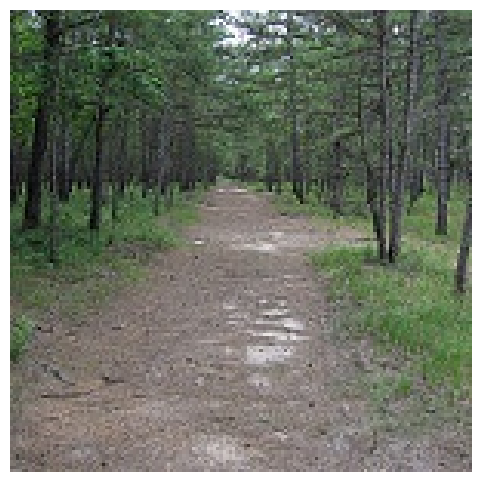

In [ ]:
image_path = "/content/intel_dataset/seg_test/seg_test/forest/20056.jpg"

from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(image_path)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
inputs = processor(images=image, return_tensors="pt")

print(inputs.keys())

KeysView({'pixel_values': tensor([[[[-0.0902, -0.0902, -0.0902,  ..., -0.0667, -0.0667, -0.0667],
          [-0.0902, -0.0902, -0.0902,  ..., -0.0667, -0.0667, -0.0667],
          [-0.0902, -0.0902, -0.0902,  ..., -0.0667, -0.0667, -0.0667],
          ...,
          [-0.2784, -0.2784, -0.2784,  ..., -0.2863, -0.2863, -0.2863],
          [-0.2549, -0.2549, -0.2549,  ..., -0.2941, -0.2941, -0.2863],
          [-0.2314, -0.2314, -0.2314,  ..., -0.2863, -0.2863, -0.2863]],

         [[-0.0118, -0.0118, -0.0118,  ...,  0.0118,  0.0118,  0.0118],
          [-0.0118, -0.0118, -0.0118,  ...,  0.0118,  0.0118,  0.0118],
          [-0.0118, -0.0118, -0.0118,  ...,  0.0118,  0.0118,  0.0118],
          ...,
          [-0.1059, -0.1059, -0.1059,  ..., -0.1137, -0.1137, -0.1137],
          [-0.0824, -0.0824, -0.0824,  ..., -0.1216, -0.1216, -0.1137],
          [-0.0588, -0.0588, -0.0588,  ..., -0.1137, -0.1137, -0.1137]],

         [[ 0.0824,  0.0824,  0.0824,  ...,  0.1059,  0.1059,  0.1059],
    

In [ ]:
with torch.no_grad():
    outputs = model(**inputs)

predicted_class = outputs.logits.argmax(-1).item()

print("Predicted Class Index:", predicted_class)

label = model.config.id2label[predicted_class]

print("Predicted Label:", label)

Predicted Class Index: 970
Predicted Label: alp


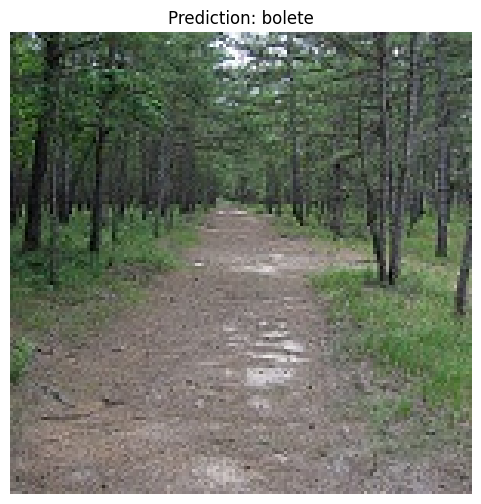

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(image)

plt.axis("off")

plt.title("Prediction: " + label)

plt.show()

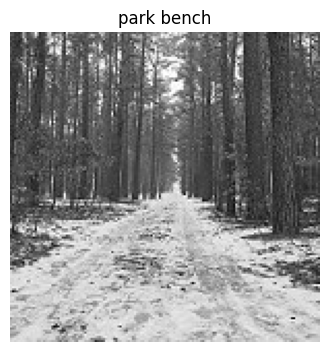

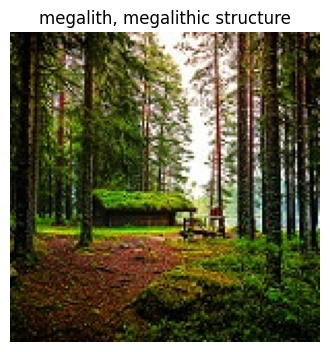

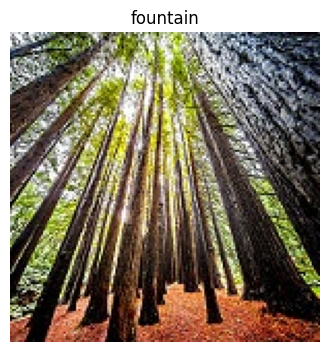

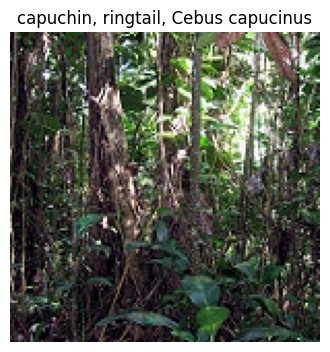

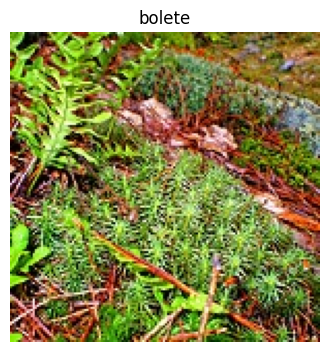

Collected true and predicted labels.


In [ ]:
import glob

# Initialize lists to store true and predicted labels
true_labels_list = []
predicted_labels_list = []

test_images = glob.glob("/content/intel_dataset/seg_test/seg_test/forest/*.jpg")

# The true label for all these images is "forest" based on the folder name
true_class_name = "forest"

for img_path in test_images[:5]: # Processing first 5 images as in original cell

    image = Image.open(img_path)

    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    predicted_class_idx = outputs.logits.argmax(-1).item()
    predicted_label = model.config.id2label[predicted_class_idx]

    # Append true and predicted labels to our lists
    true_labels_list.append(true_class_name)
    predicted_labels_list.append(predicted_label)

    plt.figure(figsize=(4,5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(predicted_label) # Display predicted label in plot title
    plt.show()

# Make the lists available for subsequent cells
global true_labels
global predicted_labels
true_labels = true_labels_list
predicted_labels = predicted_labels_list

print("Collected true and predicted labels.")

2.another method

In [ ]:
#STEP 1 Tensor Creation

import torch

# Create a random image tensor with shape (batch, channels, height, width)
# batch=1  : one image at a time
# channels=3: R, G, B
# 224x224  : spatial dimensions (standard ImageNet size)
image = torch.randn(1, 3, 224, 224)

# .shape returns a torch.Size object showing (N, C, H, W)
print(image.shape)

# Extra: check data type and device
print(image.dtype)   # default is float32
print(image.device)  # cpu by default

#STEP 2 Convolution Layer

import torch
import torch.nn as nn

# in_channels=3  : matches the 3 RGB channels of the input
# out_channels=16: learns 16 different filters (feature maps)
# kernel_size=3   : each filter covers a 3×3 pixel region
# stride=1        : slide filter one pixel at a time
# padding=1       : add 1 zero-pixel border so output H,W matches input
conv = nn.Conv2d(
    in_channels=3,
    out_channels=16,
    kernel_size=3,
    stride=1,
    padding=1
)

#STEP 3 ReLU Activation Function
import torch
import torch.nn as nn

relu = nn.ReLU()

# Sample values: negative, zero, positive
x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])




torch.Size([1, 3, 224, 224])
torch.float32
cpu


*3*.compare model

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Training Shape: (10000, 32, 32, 3)
Testing Shape: (2000, 32, 32, 3)

Training CNN...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.3196 - loss: 1.8627 - val_accuracy: 0.4240 - val_loss: 1.5916
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4450 - loss: 1.5228 - val_accuracy: 0.4910 - val_loss: 1.3936
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5071 - loss: 1.3648 - val_accuracy: 0.5260 - val_loss: 1.2917
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5582 - loss: 1.2263 - val_accuracy: 0.5385 - val_loss: 1.2963
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6103 - loss: 1.0892 - val_accuracy: 0.5705 - val_loss: 1.2115

Training MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 93ms/step - accuracy: 0.6439 - loss: 1.0454 - va

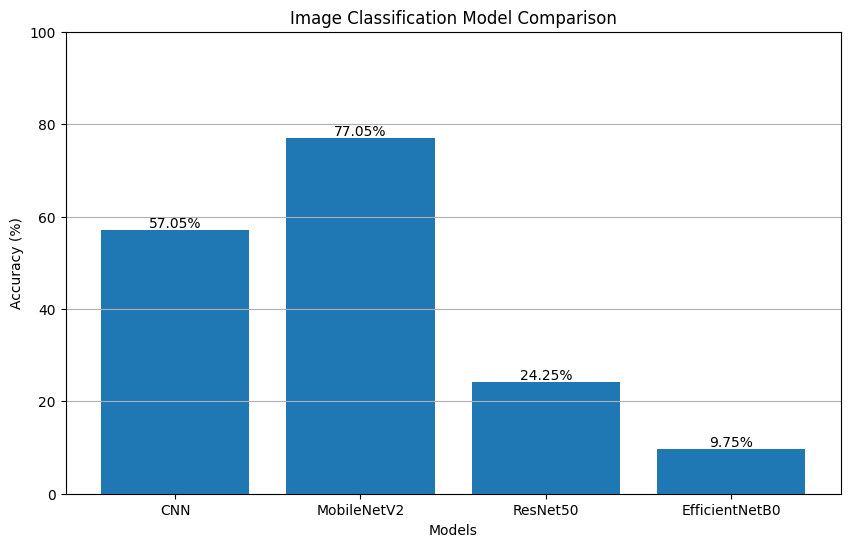


Best Model: MobileNetV2
Best Accuracy: 77.05 %


In [ ]:
!pip install tensorflow matplotlib pandas

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
import gc

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# =====================================================
# LOAD CIFAR-10 DATASET
# =====================================================

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Use subset to reduce memory usage
X_train = X_train[:10000]
y_train = y_train[:10000]

X_test = X_test[:2000]
y_test = y_test[:2000]

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# =====================================================
# CREATE DATASET PIPELINE
# =====================================================

IMG_SIZE = 96
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

results = {}

# =====================================================
# CUSTOM CNN
# =====================================================

print("\nTraining CNN...")

cnn = models.Sequential([
    layers.Input(shape=(96,96,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds,
    verbose=1
)

loss, acc = cnn.evaluate(test_ds, verbose=0)
results["CNN"] = acc * 100

tf.keras.backend.clear_session()
gc.collect()

# =====================================================
# FUNCTION FOR TRANSFER LEARNING MODELS
# =====================================================

def train_pretrained(base_model_fn, model_name):

    print(f"\nTraining {model_name}...")

    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(96,96,3)
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_ds,
        epochs=3,
        validation_data=test_ds,
        verbose=1
    )

    loss, acc = model.evaluate(test_ds, verbose=0)

    results[model_name] = acc * 100

    tf.keras.backend.clear_session()
    gc.collect()

# =====================================================
# MOBILE NET V2
# =====================================================

train_pretrained(
    MobileNetV2,
    "MobileNetV2"
)

# =====================================================
# RESNET50
# =====================================================

train_pretrained(
    ResNet50,
    "ResNet50"
)

# =====================================================
# EFFICIENTNET B0
# =====================================================

train_pretrained(
    EfficientNetB0,
    "EfficientNetB0"
)

# =====================================================
# RESULTS
# =====================================================

print("\n============================")
print("MODEL ACCURACY COMPARISON")
print("============================")

for model, accuracy in results.items():
    print(f"{model:15s} : {accuracy:.2f}%")

# =====================================================
# BAR GRAPH
# =====================================================

model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,6))

bars = plt.bar(model_names, accuracies)

plt.title("Image Classification Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.5,
        f"{y:.2f}%",
        ha='center'
    )

plt.ylim(0,100)
plt.grid(axis='y')

plt.show()

# =====================================================
# BEST MODEL
# =====================================================

best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", round(results[best_model],2), "%")



:above program using another dataset(Fashion MNIST Contains)

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original Training Shape: (60000, 28, 28)
Original Testing Shape : (10000, 28, 28)
RGB Training Shape: (10000, 28, 28, 3)
RGB Testing Shape : (2000, 28, 28, 3)

Training CNN Model...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.7669 - loss: 0.6467 - val_accuracy: 0.8325 - val_loss: 0.4631
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8509 - loss: 0.4154 - val_accuracy: 0.8645 - val_loss: 0.3874
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8787 - loss: 0.3347 - val_accuracy: 0.8715 - val_loss: 0.3981
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8936 - loss: 0.2900 - val_accuracy: 0.8840 - val_loss: 0.3514
Epoch 5/

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



MODEL ACCURACY COMPARISON
CNN             : 88.50%
MobileNetV2     : 87.30%
ResNet50        : 67.40%
EfficientNetB0  : 9.85%


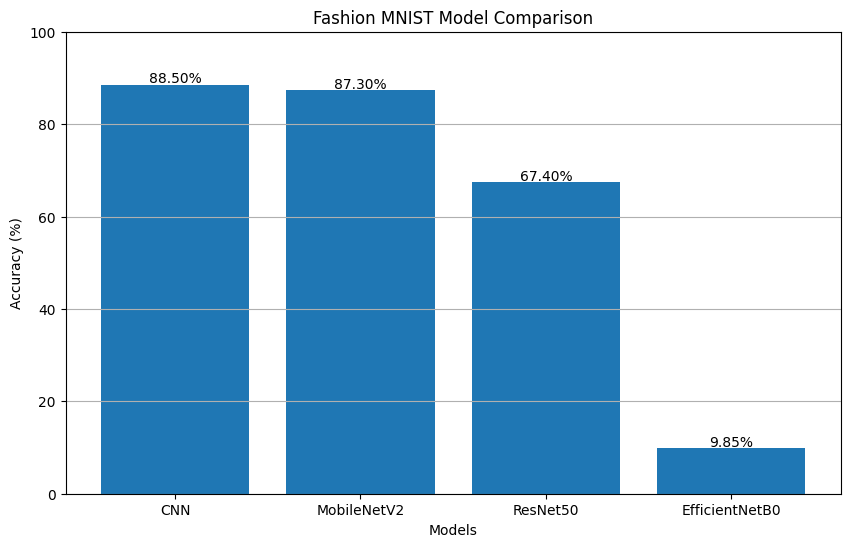


BEST MODEL
Best Model    : CNN
Best Accuracy : 88.5 %


In [ ]:
# =========================================================
# FASHION MNIST IMAGE CLASSIFICATION PROJECT
# CNN vs MobileNetV2 vs ResNet50 vs EfficientNetB0
# =========================================================

# =========================================================
# STEP 1: INSTALL LIBRARIES
# =========================================================

!pip install tensorflow matplotlib pandas scikit-learn -q

# =========================================================
# STEP 2: IMPORT LIBRARIES
# =========================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gc

from tensorflow.keras import layers, models

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import EfficientNetB0

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# =========================================================
# STEP 3: CHECK GPU
# =========================================================

print("TensorFlow Version:", tf.__version__)

print("GPU Available:", tf.config.list_physical_devices('GPU'))

# =========================================================
# STEP 4: LOAD FASHION MNIST DATASET
# =========================================================

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Original Training Shape:", X_train.shape)

print("Original Testing Shape :", X_test.shape)

# =========================================================
# STEP 5: REDUCE DATASET SIZE
# =========================================================

X_train = X_train[:10000]
y_train = y_train[:10000]

X_test = X_test[:2000]
y_test = y_test[:2000]

# =========================================================
# STEP 6: NORMALIZE IMAGES
# =========================================================

X_train = X_train.astype("float32") / 255.0

X_test = X_test.astype("float32") / 255.0

# =========================================================
# STEP 7: CONVERT GRAYSCALE TO RGB
# =========================================================

X_train = np.stack((X_train,)*3, axis=-1)

X_test = np.stack((X_test,)*3, axis=-1)

print("RGB Training Shape:", X_train.shape)

print("RGB Testing Shape :", X_test.shape)

# =========================================================
# STEP 8: IMAGE SETTINGS
# =========================================================

IMG_SIZE = 96

BATCH_SIZE = 32

# =========================================================
# STEP 9: PREPROCESS FUNCTION
# =========================================================

def preprocess(image, label):

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    return image, label

# =========================================================
# STEP 10: CREATE TRAIN DATASET
# =========================================================

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))

train_ds = train_ds.shuffle(1000)

train_ds = train_ds.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(BATCH_SIZE)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

# =========================================================
# STEP 11: CREATE TEST DATASET
# =========================================================

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

test_ds = test_ds.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE)

test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# =========================================================
# STEP 12: RESULTS DICTIONARY
# =========================================================

results = {}

# =========================================================
# STEP 13: BUILD CNN MODEL
# =========================================================

print("\nTraining CNN Model...")

cnn = models.Sequential([

    layers.Input(shape=(96,96,3)),

    layers.Conv2D(32, (3,3), activation='relu'),

    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

# =========================================================
# STEP 14: COMPILE CNN MODEL
# =========================================================

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================================
# STEP 15: TRAIN CNN MODEL
# =========================================================

cnn.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds,
    verbose=1
)

# =========================================================
# STEP 16: CNN EVALUATION
# =========================================================

y_pred_probs = cnn.predict(test_ds)

y_pred = np.argmax(y_pred_probs, axis=1)

y_true = y_test.flatten()

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("\n============================")
print("CNN RESULTS")
print("============================")

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)

results["CNN"] = accuracy * 100

# =========================================================
# STEP 17: CLEAR MEMORY
# =========================================================

tf.keras.backend.clear_session()

gc.collect()

# =========================================================
# STEP 18: FUNCTION FOR PRETRAINED MODELS
# =========================================================

def train_pretrained(base_model_fn, model_name):

    print(f"\nTraining {model_name}...")

    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(96,96,3)
    )

    base_model.trainable = False

    model = models.Sequential([

        base_model,

        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation='relu'),

        layers.Dropout(0.3),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_ds,
        epochs=3,
        validation_data=test_ds,
        verbose=1
    )

    y_pred_probs = model.predict(test_ds)

    y_pred = np.argmax(y_pred_probs, axis=1)

    y_true = y_test.flatten()

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    print("\n============================")
    print(f"{model_name} RESULTS")
    print("============================")

    print("Accuracy :", accuracy)

    print("Precision:", precision)

    print("Recall   :", recall)

    print("F1 Score :", f1)

    results[model_name] = accuracy * 100

    tf.keras.backend.clear_session()

    gc.collect()

# =========================================================
# STEP 19: TRAIN MOBILENETV2
# =========================================================

train_pretrained(
    MobileNetV2,
    "MobileNetV2"
)

# =========================================================
# STEP 20: TRAIN RESNET50
# =========================================================

train_pretrained(
    ResNet50,
    "ResNet50"
)

# =========================================================
# STEP 21: TRAIN EFFICIENTNETB0
# =========================================================

train_pretrained(
    EfficientNetB0,
    "EfficientNetB0"
)

# =========================================================
# STEP 22: MODEL COMPARISON
# =========================================================

print("\n============================")
print("MODEL ACCURACY COMPARISON")
print("============================")

for model, accuracy in results.items():

    print(f"{model:15s} : {accuracy:.2f}%")

# =========================================================
# STEP 23: BAR GRAPH USING MATPLOTLIB
# =========================================================

model_names = list(results.keys())

accuracies = list(results.values())

plt.figure(figsize=(10,6))

bars = plt.bar(model_names, accuracies)

plt.title("Fashion MNIST Model Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy (%)")

for bar in bars:

    y = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.5,
        f"{y:.2f}%",
        ha='center'
    )

plt.ylim(0,100)

plt.grid(axis='y')

plt.show()

# =========================================================
# STEP 24: BEST MODEL
# =========================================================

best_model = max(results, key=results.get)

print("\n============================")
print("BEST MODEL")
print("============================")

print("Best Model    :", best_model)

print("Best Accuracy :", round(results[best_model], 2), "%")

using flower dataset

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.WXBS36_3.0.1/tf_flowers-train.tfrecord-[0-9][0-9][0-…

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Dataset Loaded Successfully
Flower Classes:
0 : dandelion
1 : daisy
2 : tulips
3 : sunflowers
4 : roses

Training CNN Model...
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - accuracy: 0.3866 - loss: 1.3921 - val_accuracy: 0.5095 - val_loss: 1.1542
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5555 - loss: 1.0849 - val_accuracy: 0.5913 - val_loss: 1.0101
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6240 - loss: 0.9491 - val_accuracy: 0.6608 - val_loss: 0.8785
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6717 - loss: 0.8412 - val_accuracy: 0.6649 - val_loss: 0.8586
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7139 - loss: 0.7399 - val_accuracy: 0.6785 - val_loss: 0.8127
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/ste

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



MODEL ACCURACY COMPARISON
CNN             : 67.85%
MobileNetV2     : 85.69%
ResNet50        : 39.78%
EfficientNetB0  : 21.66%


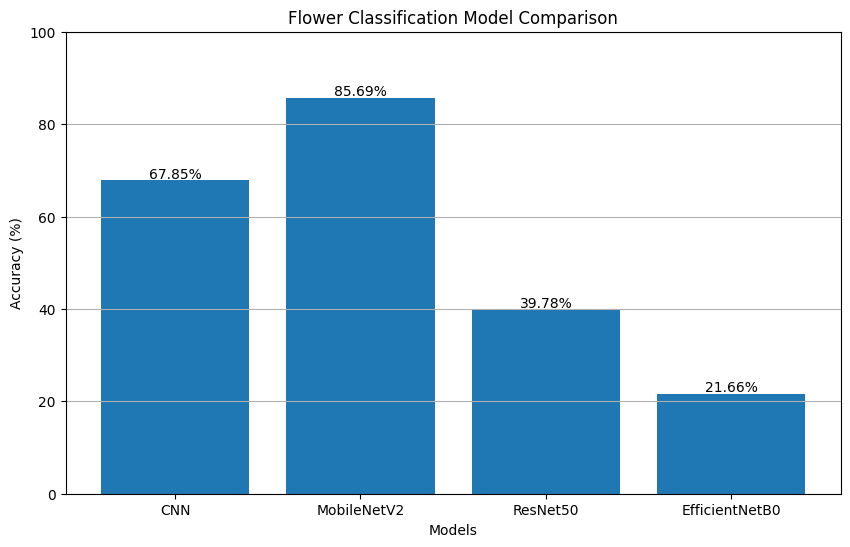


BEST MODEL
Best Model    : MobileNetV2
Best Accuracy : 85.69 %


In [ ]:
# =========================================================
# FLOWER CLASSIFICATION PROJECT
# CNN vs MobileNetV2 vs ResNet50 vs EfficientNetB0
# USING TENSORFLOW FLOWERS DATASET
# =========================================================

# =========================================================
# STEP 1: INSTALL LIBRARIES
# =========================================================

!pip install tensorflow matplotlib pandas scikit-learn tensorflow-datasets -q

# =========================================================
# STEP 2: IMPORT LIBRARIES
# =========================================================

import tensorflow as tf
import tensorflow_datasets as tfds

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gc

from tensorflow.keras import layers, models

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import EfficientNetB0

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# =========================================================
# STEP 3: CHECK GPU
# =========================================================

print("TensorFlow Version:", tf.__version__)

print("GPU Available:", tf.config.list_physical_devices('GPU'))

# =========================================================
# STEP 4: LOAD FLOWERS DATASET
# =========================================================

(dataset_train, dataset_test), dataset_info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

print("Dataset Loaded Successfully")

# =========================================================
# STEP 5: CLASS NAMES
# =========================================================

class_names = dataset_info.features['label'].names

print("Flower Classes:")

for i, name in enumerate(class_names):

    print(i, ":", name)

# =========================================================
# STEP 6: IMAGE SETTINGS
# =========================================================

IMG_SIZE = 96

BATCH_SIZE = 32

NUM_CLASSES = len(class_names)

# =========================================================
# STEP 7: PREPROCESS FUNCTION
# =========================================================

def preprocess(image, label):

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = image / 255.0

    return image, label

# =========================================================
# STEP 8: PREPARE TRAIN DATASET
# =========================================================

train_ds = dataset_train.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.shuffle(1000)

train_ds = train_ds.batch(BATCH_SIZE)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

# =========================================================
# STEP 9: PREPARE TEST DATASET
# =========================================================

test_ds = dataset_test.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE)

test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# =========================================================
# STEP 10: RESULTS DICTIONARY
# =========================================================

results = {}

# =========================================================
# STEP 11: BUILD CNN MODEL
# =========================================================

print("\nTraining CNN Model...")

cnn = models.Sequential([

    layers.Input(shape=(96,96,3)),

    layers.Conv2D(32, (3,3), activation='relu'),

    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

# =========================================================
# STEP 12: COMPILE CNN MODEL
# =========================================================

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================================
# STEP 13: TRAIN CNN MODEL
# =========================================================

cnn.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds,
    verbose=1
)

# =========================================================
# STEP 14: CNN EVALUATION
# =========================================================

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = cnn.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("\n============================")
print("CNN RESULTS")
print("============================")

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)

results["CNN"] = accuracy * 100

# =========================================================
# STEP 15: CLEAR MEMORY
# =========================================================

tf.keras.backend.clear_session()

gc.collect()

# =========================================================
# STEP 16: FUNCTION FOR PRETRAINED MODELS
# =========================================================

def train_pretrained(base_model_fn, model_name):

    print(f"\nTraining {model_name}...")

    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(96,96,3)
    )

    base_model.trainable = False

    model = models.Sequential([

        base_model,

        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation='relu'),

        layers.Dropout(0.3),

        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_ds,
        epochs=3,
        validation_data=test_ds,
        verbose=1
    )

    y_true = []
    y_pred = []

    for images, labels in test_ds:

        predictions = model.predict(images)

        predicted_labels = np.argmax(predictions, axis=1)

        y_true.extend(labels.numpy())

        y_pred.extend(predicted_labels)

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    print("\n============================")
    print(f"{model_name} RESULTS")
    print("============================")

    print("Accuracy :", accuracy)

    print("Precision:", precision)

    print("Recall   :", recall)

    print("F1 Score :", f1)

    results[model_name] = accuracy * 100

    tf.keras.backend.clear_session()

    gc.collect()

# =========================================================
# STEP 17: TRAIN MOBILENETV2
# =========================================================

train_pretrained(
    MobileNetV2,
    "MobileNetV2"
)

# =========================================================
# STEP 18: TRAIN RESNET50
# =========================================================

train_pretrained(
    ResNet50,
    "ResNet50"
)

# =========================================================
# STEP 19: TRAIN EFFICIENTNETB0
# =========================================================

train_pretrained(
    EfficientNetB0,
    "EfficientNetB0"
)

# =========================================================
# STEP 20: MODEL COMPARISON
# =========================================================

print("\n============================")
print("MODEL ACCURACY COMPARISON")
print("============================")

for model, accuracy in results.items():

    print(f"{model:15s} : {accuracy:.2f}%")

# =========================================================
# STEP 21: BAR GRAPH USING MATPLOTLIB
# =========================================================

model_names = list(results.keys())

accuracies = list(results.values())

plt.figure(figsize=(10,6))

bars = plt.bar(model_names, accuracies)

plt.title("Flower Classification Model Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy (%)")

for bar in bars:

    y = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.5,
        f"{y:.2f}%",
        ha='center'
    )

plt.ylim(0,100)

plt.grid(axis='y')

plt.show()

# =========================================================
# STEP 22: BEST MODEL
# =========================================================

best_model = max(results, key=results.get)

print("\n============================")
print("BEST MODEL")
print("============================")

print("Best Model    :", best_model)

print("Best Accuracy :", round(results[best_model], 2), "%")